In [38]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Activation
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

In [2]:
# 1. Load the California Housing Dataset
data = fetch_california_housing()
X, y = data.data, data.target

In [40]:
dt = pd.DataFrame(X,columns = data.feature_names)

In [41]:
dt.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

In [3]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
# 2. Preprocess the data
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)  # Standardize features
X_test_std = scaler.transform(X_test)

In [5]:
X_train_std.shape

(16512, 8)

In [32]:
# 3. Building a Multi Layered Perceptron

# Layers are arranged linearly; one after another
model = Sequential()

# Defining the input layer explicitly with shape matching the number of features
model.add(Input(shape=(X_train_std.shape[1],)))

# Adding subsequent layers

# First hidden layer connected directly with the input layer
# Need to mention the input dimension (number of features / columns)
model.add(Dense(16))

model.add(Activation('relu'))

model.add(Dense(32))

model.add(Activation('relu'))

model.add(Dense(64))

model.add(Activation('relu'))  # Activation function for non-linearity detection


# Second hidden layer with 32 neurons
# Input to this layer comes from output of first hidden layer
model.add(Dense(32))

model.add(Activation('relu'))  # ReLu = rectified linear unit


# Third hidden layer with 16 neurons
# Input dimension is automatically inferred
model.add(Dense(16))

model.add(Activation('relu'))

# Output layer with 1 neuron
model.add(Dense(1))

model.add(Activation('linear'))  # Activation function for regression

In [33]:
# 4. Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='mse',
              metrics=['mae'])  # Mean Absolute Error (MAE) for evaluation

In [34]:
# 5. Train the model

history = model.fit(X_train_std, y_train,
                    epochs=20,
                    batch_size=32,
                    validation_split=0.2,
                    verbose=1)

Epoch 1/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.8824 - mae: 0.6555 - val_loss: 0.4864 - val_mae: 0.4991
Epoch 2/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4237 - mae: 0.4669 - val_loss: 0.4364 - val_mae: 0.4622
Epoch 3/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3857 - mae: 0.4444 - val_loss: 0.4007 - val_mae: 0.4454
Epoch 4/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3688 - mae: 0.4320 - val_loss: 0.3947 - val_mae: 0.4376
Epoch 5/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3524 - mae: 0.4212 - val_loss: 0.3847 - val_mae: 0.4490
Epoch 6/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3384 - mae: 0.4104 - val_loss: 0.3589 - val_mae: 0.4228
Epoch 7/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3291 - mae: 0.4028 - val_loss: 0.3528 - val_mae: 0.4151
Epoch 8/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3212 - mae: 0.3946 - val_loss: 0.3409 - val_mae: 0.3939
Epoch 9/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

In [35]:
# 6. Evaluate the model
loss, mae = model.evaluate(X_test_std, y_test, verbose=0)
print(f"Test Mean Absolute Error: {mae:.2f}")

Test Mean Absolute Error: 0.37


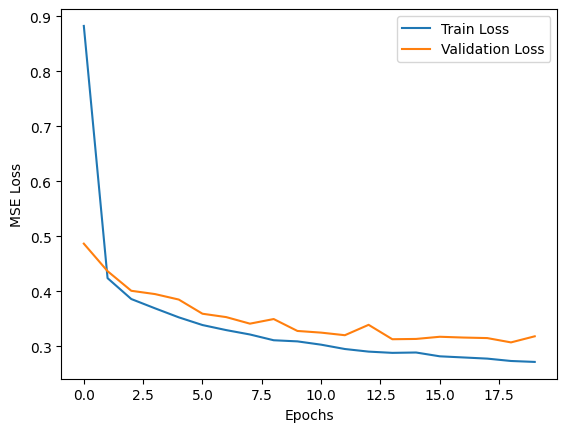

In [36]:
# 7. Plot training and validation loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

### Observation

We see that:

    1. By increaing the number of layers we and the nurons we give the model to learn more about the train data, here we see that even if we increse the nurons to 128 we see a dcrese in the loss but the time it takes for each epoch is quite high so for ease of computaion and time we increase just the layers.
    2. By increaing the epoch we allow the model to do more updation in the weights and biases but if we increase the learning rate from 0.001 to 0.01 we see that the updates occur more frequently and we see drop in loss in each epoch but we see that the val_loss oscillates if we donot make any changes to the number of neurons and layers 
    3. By increasing the epoch as we see that in 10 epochs we see that the loss continues to decrease and by increasing it to 20 epoch the loss almost stagnates.
    4. But if we just increse the learning rate from 0.001 to 0.01 and have epoch of 10 we see that the loss osciilates after 6 epochs.